In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import scipy
import pandas as pd

model_name = "Qwen/Qwen3-4B"

tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
def detect2(text, tokenizer, vocab_size, gamma=0.5, k=1):
    tokens = tokenizer.encode(text, add_special_tokens=False)
    seen = set()
    green_count = 0
    T = 0
    for i in range(k, len(tokens)):
        context = tuple(tokens[i-k:i])
        key = (context, tokens[i])
        if key in seen:
            continue
        seen.add(key)
        T += 1
        seed = abs(hash(context)) % (2**32)
        gen = torch.Generator().manual_seed(seed)
        perm = torch.randperm(vocab_size, generator=gen)
        green_ids = set(perm[:int(gamma * vocab_size)].tolist())
        if tokens[i] in green_ids:
            green_count += 1
    z = (green_count - gamma * T) / (gamma * (1 - gamma) * T) ** 0.5
    p = 1 - scipy.stats.norm.cdf(z)
    return z, p

In [120]:
import pandas as pd

df_not_wm = pd.read_csv("./generated_responses_100_context.csv")
df_w = pd.read_csv("./generated_responses_100_watermaked_no_context.csv")

In [121]:
df_w

,instruction,context,response,category,generated_response
0,What are the best selling albums of all time? ...,NaN,Best selling albums of all time:\n\n- Michael ...,brainstorming,Here is a list of the **best-selling albums of...
1,"Given this paragraph about magnesium, what is ...",Elemental magnesium is a gray-white lightweigh...,The melting point of magnesium is 650 °C.,closed_qa,To determine the melting point of magnesium fr...
2,How do I pick the best bananas?,NaN,It depends on when you want to eat them. If yo...,general_qa,Picking the best bananas is a simple process t...
3,Extract the teams that Bob Sanders played thro...,"Demond ""Bob"" Sanders (born February 24, 1981) ...","Iowa Hawkeyes, Indianapolis Colts, San Diego C...",information_extraction,Bob Sanders (baseball) played for the followin...
4,Who was the 27th president of the United State...,NaN,William Howard Taft was the 27th president of ...,open_qa,The 27th president of the United States was **...
...,...,...,...,...,...
95,What is quantum mechanics?,NaN,"In a more general sense, the word ​“quantum” c...",general_qa,Quantum mechanics is a fundamental theory in p...
96,Provide a list of ingredients to fill a burrit...,"Burritos are filled with savory ingredients, m...","I’d fill a burrito with chicken, rice, refried...",information_extraction,Sure! Here's a classic list of ingredients to ...
97,What are the most powerful server CPUs?,NaN,AMD EPYC and Intel Xeon are among the most pow...,open_qa,"The ""most powerful server CPUs"" can be subject..."
98,"Given a reference text about Kostas Georgakis,...",Kostas Georgakis (Greek: Κώστας Γεωργάκης) (23...,"Kostas Georgakis went to Genoa, Italy in 1967 ...",closed_qa,Based on the reference text about Kostas Georg...


In [122]:
human_responses = df_not_wm["response"].tolist()
ai_responses_not_wm = [text.replace("<context>", "").replace("</context>", "").strip() for text in df_not_wm["generated_response"].tolist()]
ai_responses_wm = df_w["generated_response"].tolist()

In [123]:
from tqdm import tqdm

human_responses_zp = [detect2(text, tokenizer, tokenizer.vocab_size) for text in tqdm(human_responses, total=len(human_responses))]
ai_responses_not_wm_zp = [detect2(text, tokenizer, tokenizer.vocab_size) for text in tqdm(ai_responses_not_wm, total=len(ai_responses_not_wm))]
ai_responses_wm_zp = [detect2(text, tokenizer, tokenizer.vocab_size) for text in tqdm(ai_responses_wm, total=len(ai_responses_wm))]

100%|██████████| 100/100 [03:01<00:00,  1.81s/it]


In [124]:
human_responses_zp_p = [el[1] for el in human_responses_zp]
ai_responses_not_wm_zp_p = [el[1] for el in ai_responses_not_wm_zp]
ai_responses_wm_zp_p = [el[1] for el in ai_responses_wm_zp]

human_responses_zp_z = [el[0] for el in human_responses_zp]
ai_responses_not_wm_zp_z = [el[0] for el in ai_responses_not_wm_zp]
ai_responses_wm_zp_z = [el[0] for el in ai_responses_wm_zp]

In [125]:
def detection_rate(p_values):
    return sum(p < 0.01 for p in p_values) / len(p_values)

print(detection_rate(human_responses_zp_p))      # expect ~1-2%
print(detection_rate(ai_responses_not_wm_zp_p))         # expect ~1-2%
print(detection_rate(ai_responses_wm_zp_p)) # expect ~80-100%

0.02
0.03
0.49


In [126]:
import numpy as np
print(np.mean(human_responses_zp_z))       # expect ≈ 0
print(np.mean(ai_responses_not_wm_zp_z))          # expect ≈ 0
print(np.mean(ai_responses_wm_zp_z)) # expect >> 0

0.3112218717295916
0.12400730042471947
2.271060823869097


In [127]:
import numpy as np
zs = human_responses_zp_z
print(f"mean: {np.mean(zs):.3f}, std: {np.std(zs):.3f}")
print(f"fraction with z > 2.33: {np.mean([z > 2.33 for z in zs]):.2%}")  # p < 0.01 threshold

mean: 0.311, std: 0.953
fraction with z > 2.33: 2.00%


In [128]:
import numpy as np
zs = ai_responses_not_wm_zp_z
print(f"mean: {np.mean(zs):.3f}, std: {np.std(zs):.3f}")
print(f"fraction with z > 2.33: {np.mean([z > 2.33 for z in zs]):.2%}")  # p < 0.01 threshold

mean: 0.124, std: 1.010
fraction with z > 2.33: 3.00%


In [129]:
import numpy as np
zs = ai_responses_wm_zp_z
print(f"mean: {np.mean(zs):.3f}, std: {np.std(zs):.3f}")
print(f"fraction with z > 2.33: {np.mean([z > 2.33 for z in zs]):.2%}")  # p < 0.01 threshold

mean: 2.271, std: 1.322
fraction with z > 2.33: 49.00%


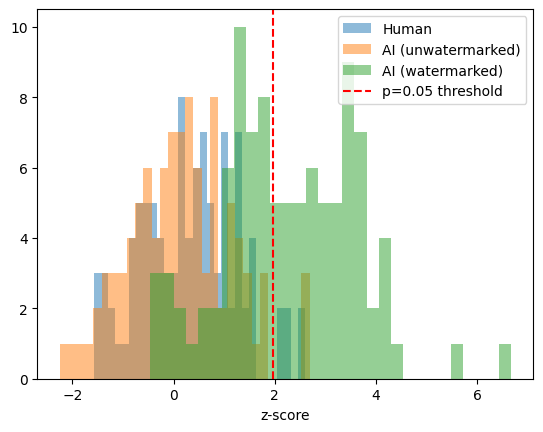

In [130]:
import matplotlib.pyplot as plt

plt.hist(human_responses_zp_z, alpha=0.5, label="Human", bins=30)
plt.hist(ai_responses_not_wm_zp_z, alpha=0.5, label="AI (unwatermarked)", bins=30)
plt.hist(ai_responses_wm_zp_z, alpha=0.5, label="AI (watermarked)", bins=30)
plt.axvline(x=1.96, color='red', linestyle='--', label="p=0.05 threshold")
plt.xlabel("z-score")
plt.legend()
plt.show()